# Pipe Diagrams with Color Codes

This fork extends tqec with initial functionality regarding a pipe diagram framework for color codes. This notebook explains what can be done and highlights the current limitations, as this is by far not a full automation.

**What we can do:**
1. Create instances of `PrismGraph` for color code pipe diagrams which is an alternative structure to the `BlockGraph` for the surface code.
2. Visualization of such a `PrismGraph` and translation into ZX diagrams.
3. Explicit geometric construction of stabilizers per timeslice for arbitrary $d$ as well as construction of string operators (=vertical correlation surface) and construction of horizontal correlation surfaces for arbitrary $d$.
4. Automated construction for syndrome extraction circuits with a combination of the superdense scheme and the inline folding scheme. The construction works for a choice of logical movements and CNOT with temporal ports. 
5. Scripts for reproducing simulation results in `cnot_sim` and `movement_sim`.

**Limitations:**
- So far, one can construct `PrismGraph` instances of objects for which no reliable syndrome extraction is possible.
- In particular open spatial ports are not supported yet.
- The construction of syndrome extraction circuits is only tested for the instances in `cnot_sim` and `movement_sim`. As long as constructions assume logical operator measurement at the last time slice in a temporal manner, one can also try out other structures.


The following file guides you through building a PrismGraph, showing the ZX diagram, constructing stabilizers and explicit correlation surfaces as well as the construction of syndrome extraction circuits.

## 1. Initialize a pipe diagram for color codes

Note that the chosen example here is not supported for automated syndrome extraction. It is just supposed to highlight the stabilizer construction etc.

In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
import temp_utils
import tqec.computation.syndrome_extraction_cc as se
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on

In [2]:
g = PrismGraph("Id")

prisms = [
    (Position3DHex(0, 0, 0), "NN", ""),
    (Position3DHex(1, 1, 0), "ZZ", ""),
    (Position3DHex(2, 0, 0), "ZZ", ""),
    (Position3DHex(3, 1, 0), "ZZ", ""),
    (Position3DHex(2, 2, 0), "ZZ", ""),
    (Position3DHex(1, 3, 0), "NN", ""),
    (Position3DHex(4, 0, 0), "NN", ""),

    (Position3DHex(0, 0, -1), "XN", ""),
    (Position3DHex(0, 0, 1), "NX", ""),

    (Position3DHex(4, 0, -1), "XN", ""),
    (Position3DHex(4, 0, 1), "NX", ""),

    (Position3DHex(1, 3, -1), "XN", ""),
    (Position3DHex(1, 3, 1), "NX", ""),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [3]:
pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)
g.add_pipe(prisms[3][0], prisms[4][0], pipe_kind)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)
g.add_pipe(prisms[3][0], prisms[6][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[7][0], pipe_kind)
g.add_pipe(prisms[0][0], prisms[8][0], pipe_kind)
g.add_pipe(prisms[6][0], prisms[9][0], pipe_kind)
g.add_pipe(prisms[6][0], prisms[10][0], pipe_kind)
g.add_pipe(prisms[5][0], prisms[11][0], pipe_kind)
g.add_pipe(prisms[5][0], prisms[12][0], pipe_kind)

In [4]:
g.view_as_html()

## 2. Create stabilizers, star operators and horizontal correlation surfaces

In [5]:
z=0 #position in z direction
d=9 #distance of single patch

#stabilizers
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers = g.stabilizers_timeslice(z, d)

#star operators (aka vertical correlation surface)
star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)

#horizontal correlation surface (choice)
result = g.stabilizer_product_timeslice(z,
                                        d,
                                        dct_single_type_stabs,
                                        dct_patch_stabilizers,
                                        testing = True
                                        )

stabilizer tests passed
stabilizer tests passed
stabilizer tests passed


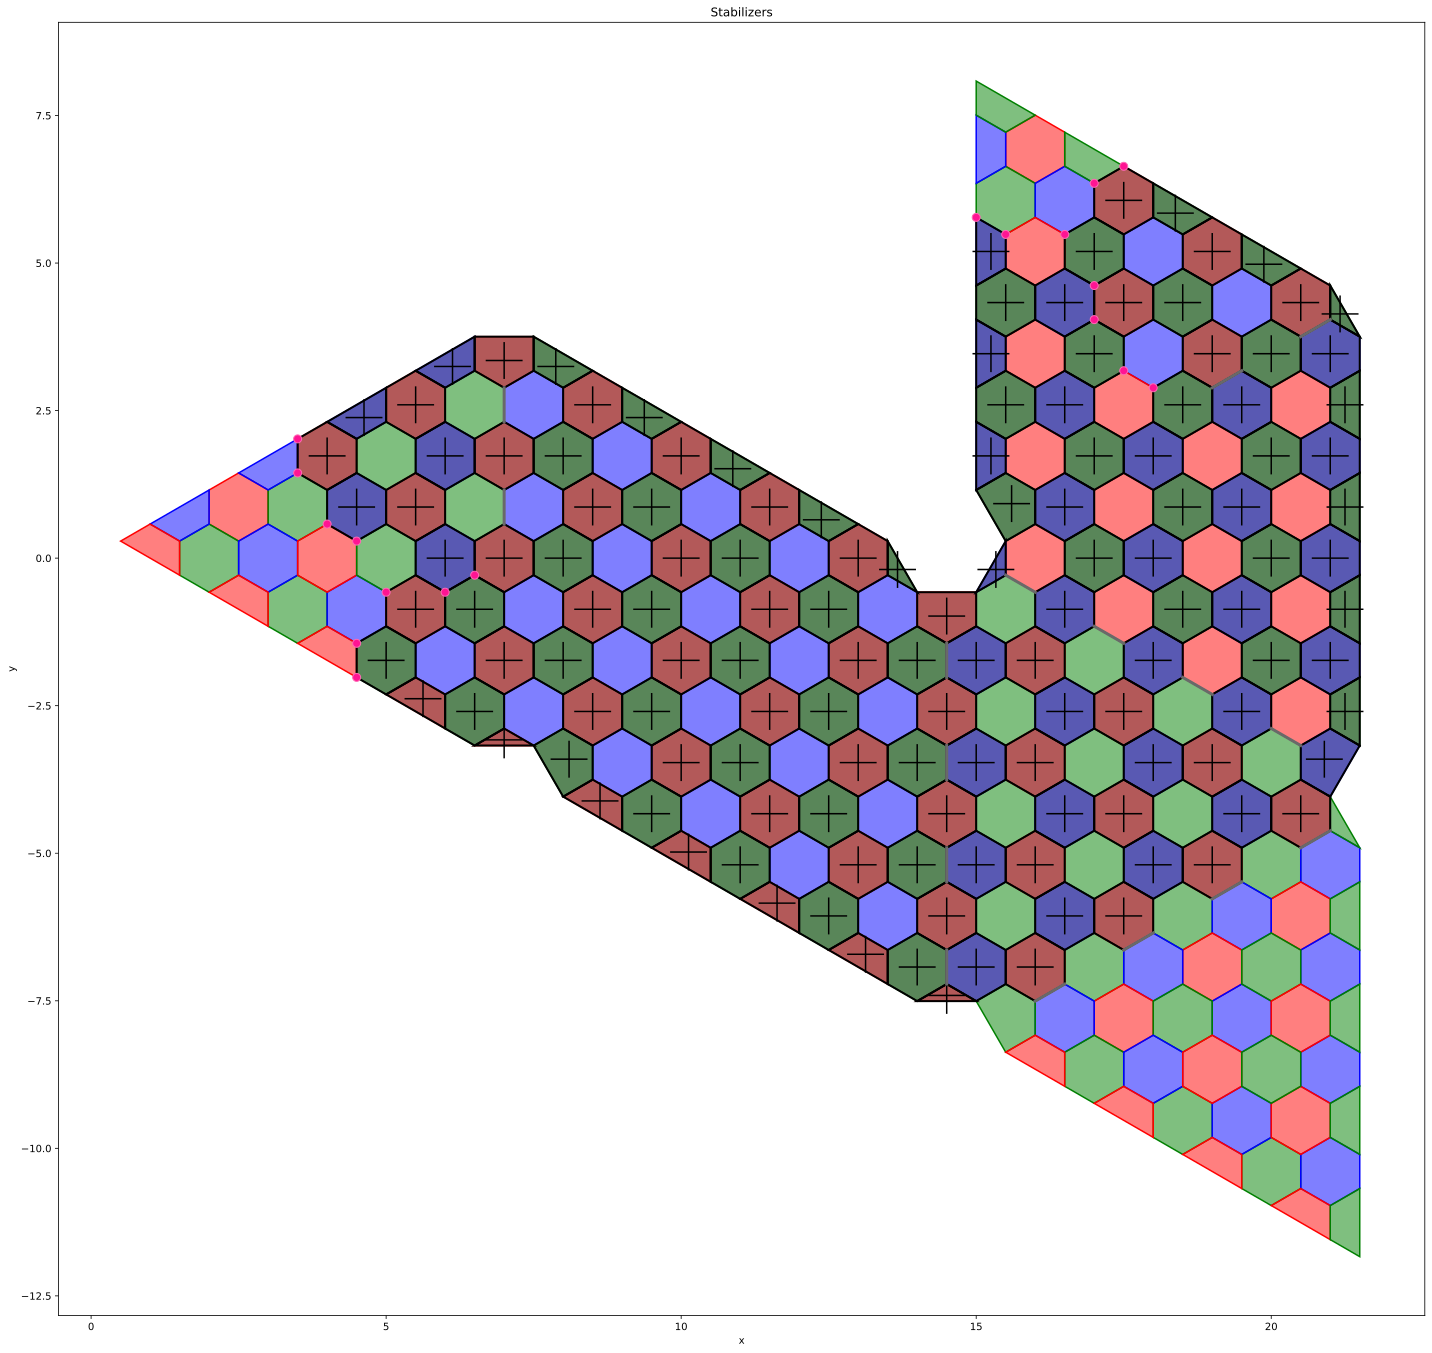

In [6]:
all_paths_stabilizer_product = result.stabilizer_products_x
idx = 0
all_paths_stars = result.stars_x


temp_utils.plot_position_dict_3color(size = (20,20),
                              color_assignment=result.assignment,
                              stabilizer_product = all_paths_stabilizer_product[idx],
                              star_operators = all_paths_stars[idx],
                              show_positions = False)


The stabilizers with shade and black cross are those in the stabilizer product $CS_X$. The weight-2 stabilizers in that set are displayed as grey line. The pink dots indicate the logical operator that is represented by that horizontal correlation surface.

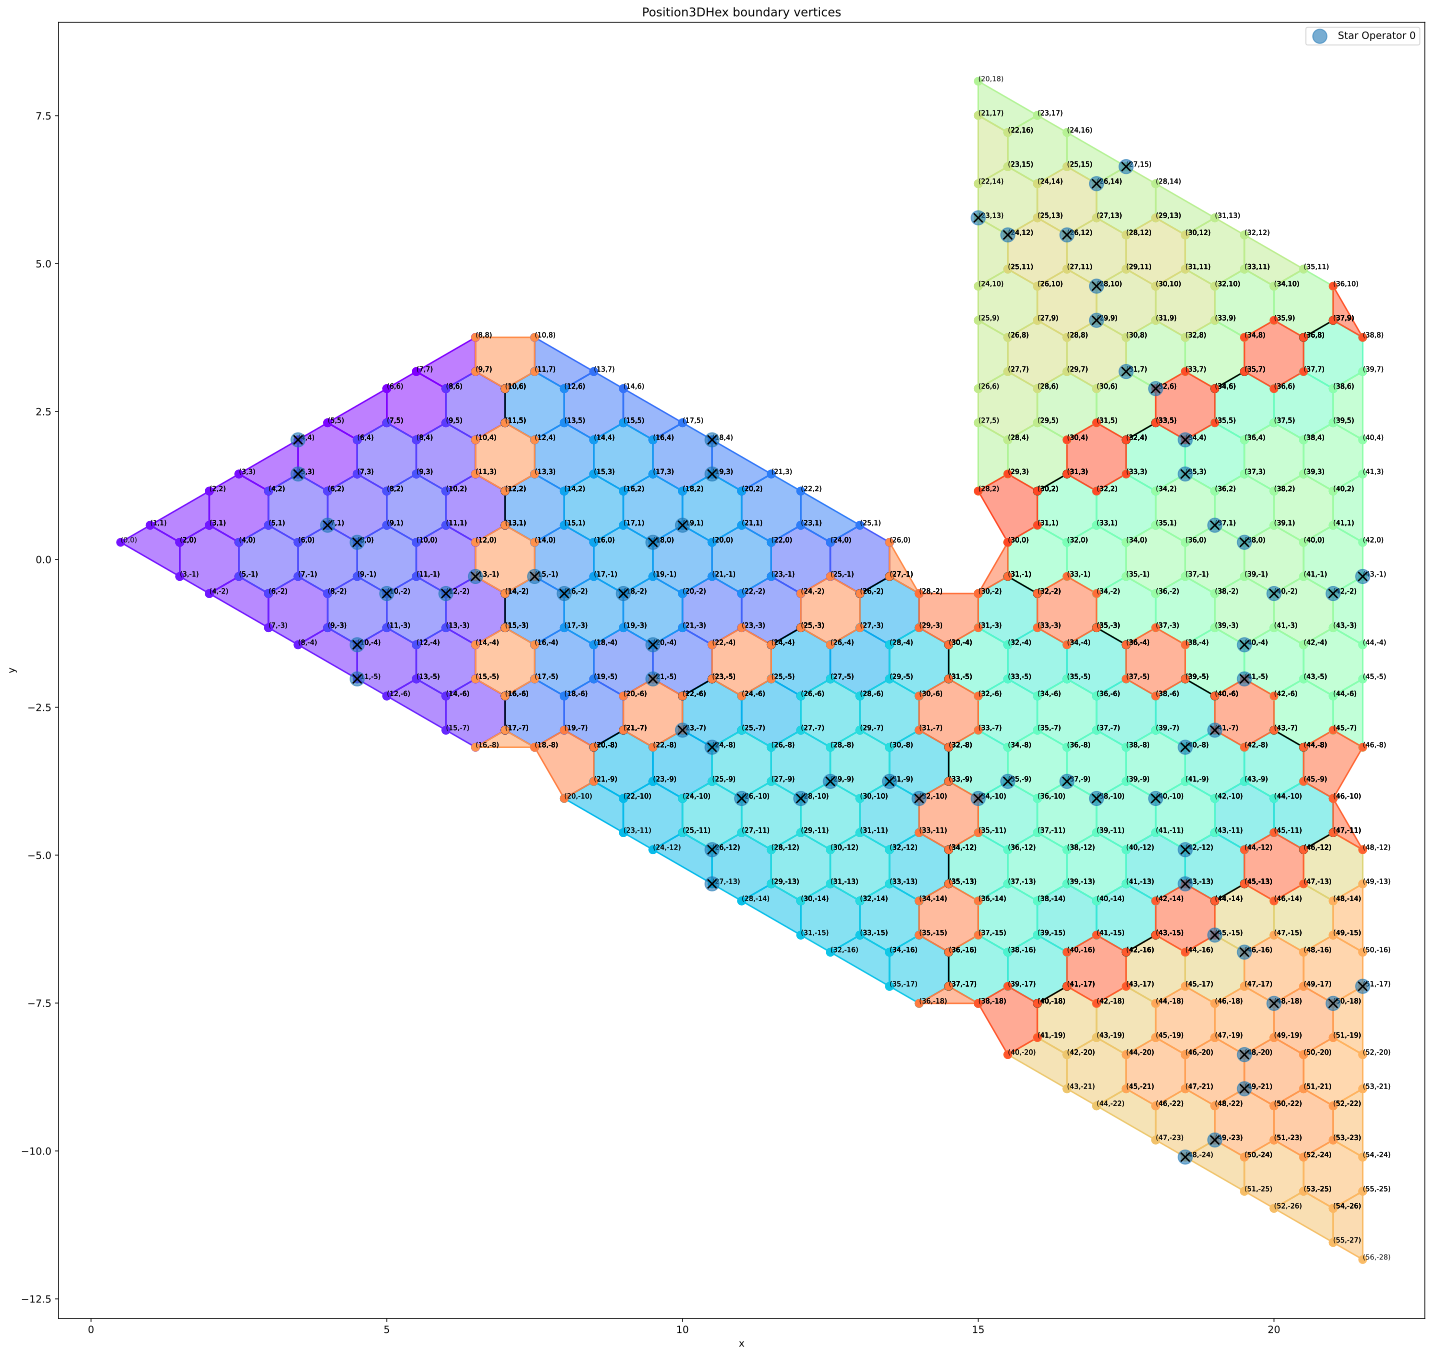

In [7]:
idx = 0
all_paths_stars = result.stars_z


temp_utils.plot_position_dict(
    size = (20,20),
    stabilizers = stabs_x,
    star_op = star_ops_z,
)

The blue dots with black crosses indicate the data qubits that are involved in the star operator (vertical correlation surface) spanning through the structure. The plaquette colors carry no meaning.

## 3. Display the object on a rectangular grid as needed for syndrome extraction

As the syndrome extraction requries a mapping of data and ancilla qubits on a rectangular lattice, let's use the class for the syndrome extraction already and display the same figure on a rectangular grid. However, let's use a smaller distance

stabilizer tests passed
stabilizer tests passed
stabilizer tests passed


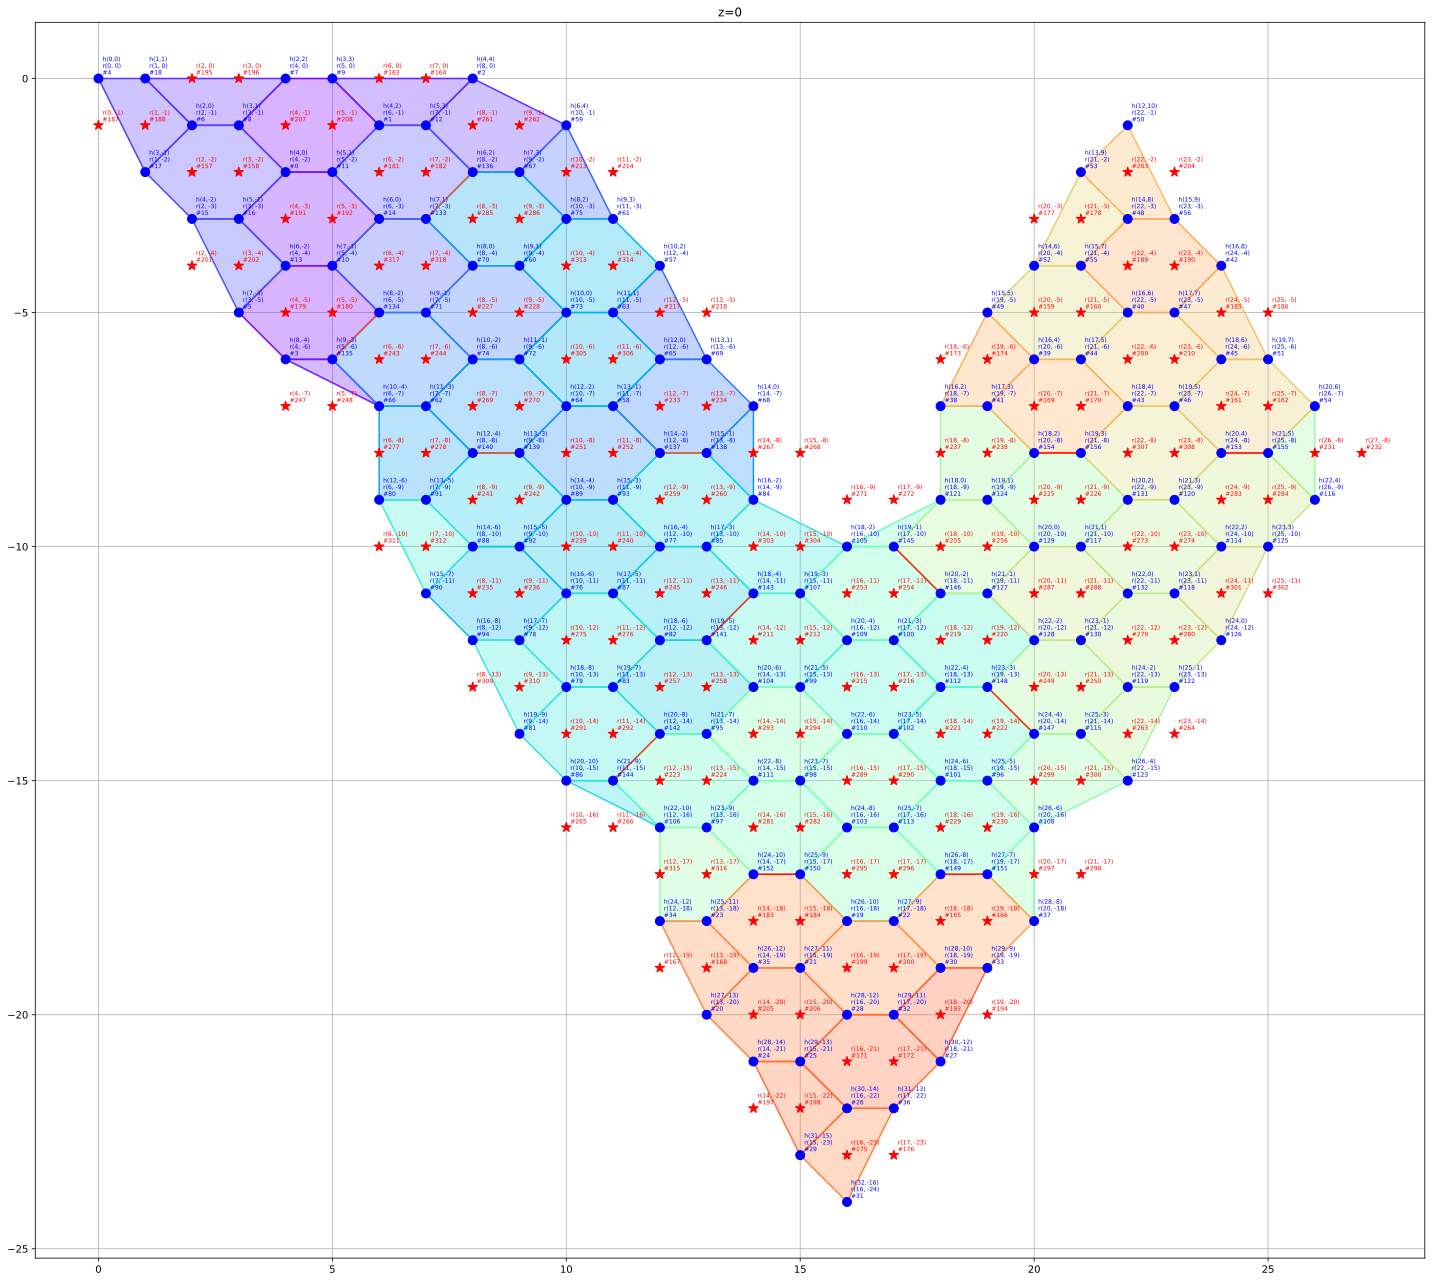

In [8]:
d=5
SE = se.SyndromeExtractionStimCC(g, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 0
temp_utils.plot_mapping_full(mapping_full, z_temp, size = (20,20))

## 4. Create ZX diagram and conclude correlation surfaces

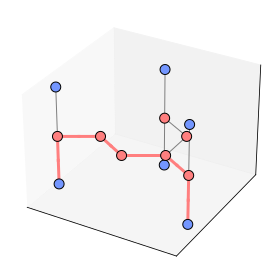

In [9]:
zx = g.to_zx_graph()
cs_lst = g.find_correlation_surfaces()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs_lst[3], zx, ax)

# 5. Build the syndrome extraction circuit for a movement.

The current implementation allows to construct a syndrome extraction circuit for the above structure as well, but it is not thoroughly tested. Thus we refer to a simple movement here

In [26]:
g = PrismGraph("two-patches")

prisms = [
    (Position3DHex(2,2,-1), "ZN", "init"),
    (Position3DHex(2,2,0), "NX", "left"),
    (Position3DHex(3,1,0), "XN", "right"),
    (Position3DHex(3,1,1), "NZ", "final"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

g.view_as_html()

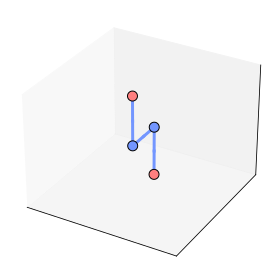

In [30]:
zx = g.to_zx_graph()
cs_lst = g.find_correlation_surfaces()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs_lst[0], zx, ax)

In [31]:
d=7
rounds = d
p = 0.001


SE = se.SyndromeExtractionStimCC(g, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs_lst = cs_lst
)

stabilizer tests passed
========================z=-1=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=8, y=-2, z=0), rect=(6, -5), label=12), PositionEntry(hex=Position3DHex(x=9, y=-1, z=0), rect=(7, -5), label=15)]
lst [12, 80]
lst [15, 81]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=4, y=-2, z=0), rect=(2, -3), label=29), PositionEntry(hex=Position3DHex(x=5, y=-1, z=0), rect=(3, -3), label=32)]
lst [29, 82]
lst [32, 83]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=6, y=-2, z=0), rect=(4, -4), label=24), PositionEntry(hex=Position3DHex(x=7, y=-1, z=0), rect=(5, -4), label=21)]
lst [24, 84]
lst [21, 85]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=11), PositionEntry(hex=Position3DHex(x=3, y=1, z=0), rect=(3, -1), label=16)]
lst [11, 86]
lst [16, 87]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=6, y=0, z=0), rect=(6, -3), label=26), PositionEntr

In [32]:
dem = circuit.detector_error_model()

In [33]:
len(circuit.shortest_graphlike_error())

7

the detector error can be built, thus the resulting circuit is reasonable.

The distance is preserved. However for the vertical correlation surface the circuit level distance is expected to be halved.

Simulating the circuits can be done with sinter and tesseract (or other general decoders).